<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

## Sampling

In [1]:
#| echo: false
#| output: asis
show_doc(Resample)

---

[source](https://github.com/bmandracchia/bioMONAI/blob/main/bioMONAI/transforms.py#L15){target="_blank" style="float:right; font-size:smaller"}

### Resample

>      Resample (sampling, **kwargs)

A subclass of Spacing that handles image resampling based on specified sampling factors or voxel dimensions.

The [`Resample`](https://bmandracchia.github.io/bioMONAI/transforms.html#resample) class inherits from `Spacing` and provides a flexible way to adjust the spacing (voxel size) of images by specifying either a sampling factor or explicitly providing new voxel dimensions.

Args:
    sampling (int, optional): Sampling factor for isotropic resampling. Default is 1, indicating no change in resolution.
    **kwargs: Additional keyword arguments that can include 'pixdim' to specify custom voxel dimensions.

Attributes:
    pixdim (list or tuple): The voxel dimensions of the image after resampling. If not provided during initialization, this will be determined based on the sampling factor and original image properties.

Methods:
    None

Example Usage:
    # Creating a Resample object with a specified sampling factor
    resampler = Resample(sampling=2)

    # Creating a Resample object with custom voxel dimensions
    resampler = Resample(**kwargs={'pixdim': [1.5, 1.5, 3]})

In [ ]:
from bioMONAI.core import cells3d, img2Tensor
from bioMONAI.visualize import visualize_slices

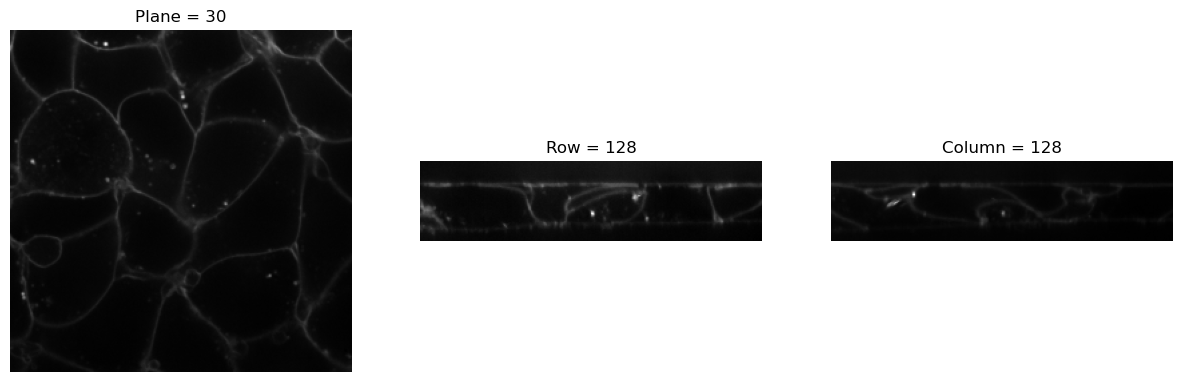

`data_array` is not of type MetaTensor, assuming affine to be identity.


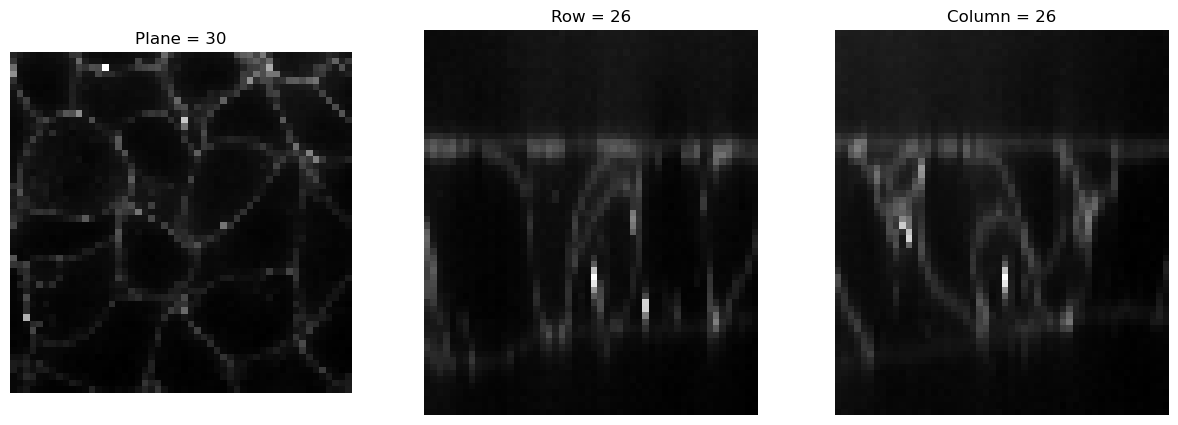

In [ ]:
img = cells3d()[:,0]

visualize_slices(img, showlines=False)

img2 = Resample(5)(img2Tensor(img))

visualize_slices(img2, showlines=False)

## Noise

In [2]:
#| echo: false
#| output: asis
show_doc(RandCameraNoise)

---

[source](https://github.com/bmandracchia/bioMONAI/blob/main/bioMONAI/transforms.py#L58){target="_blank" style="float:right; font-size:smaller"}

### RandCameraNoise

>      RandCameraNoise (input_image, qe=0.7, gain=2, exp_time=0.1,
>                       dark_current=0.06, readout=2.5, bitdepth=16, offset=100,
>                       seed=42, simulation=False, camera='cmos',
>                       gain_variance=0.1, offset_variance=5)

Simulates camera noise by adding Poisson shot noise, dark current noise, and optionally CMOS fixed pattern noise.

Args:
    input_image (numpy.ndarray): The original image as a NumPy array.
    qe (float, optional): Quantum efficiency of the camera (0 to 1). Default is 0.7.
    gain (float or numpy.ndarray, optional): Camera gain factor. If an array, it should be broadcastable with input_image shape. Default is 2.
    exp_time (float, optional): Exposure time in seconds. Default is 0.1.
    dark_current (float, optional): Dark current per pixel in electrons/second. Default is 0.06.
    readout (float, optional): Readout noise standard deviation in electrons. Default is 2.5.
    bitdepth (int, optional): Bit depth of the camera output. Default is 16.
    offset (int or float, optional): Offset value to add to each pixel after conversion to ADU. Default is 100.
    seed (int, optional): Seed for random number generator for reproducibility. Default is 42.
    simulation (bool, optional): If True, assumes input_image is already in units of photons and does not convert from electrons. Default is False.
    camera (str, optional): Specifies the type of camera ('cmos' or any other). Used to add CMOS fixed pattern noise if 'cmos' is specified. Default is 'cmos'.
    gain_variance (float, optional): Variance for the gain noise in CMOS cameras. Only applicable if camera type is 'cmos'. Default is 0.1.
    offset_variance (float, optional): Variance for the offset noise in CMOS cameras. Only applicable if camera type is 'cmos'. Default is 5.

Returns:
    numpy.ndarray: The noisy image as a NumPy array with dimensions of input_image.

In [ ]:
from bioMONAI.visualize import plot_image

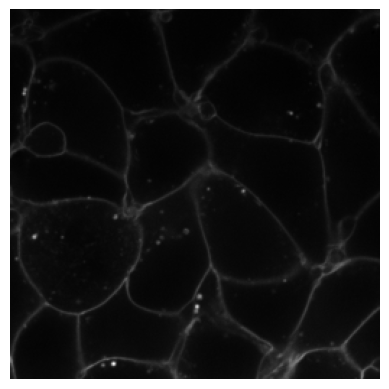

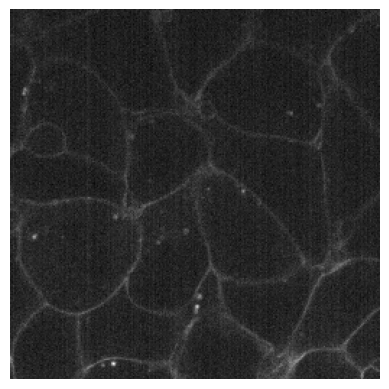

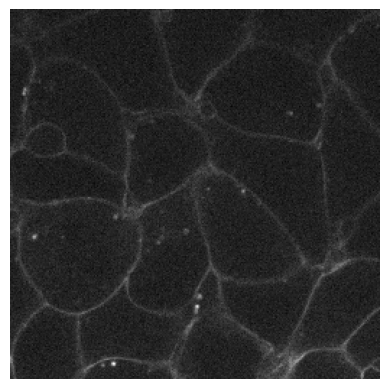

In [ ]:
plot_image(img[30])
plot_image(RandCameraNoise(.01*img[30], camera = 'cmos'))
plot_image(RandCameraNoise(.01*img[30], camera = 'ccd'))

## Normalization

In [3]:
#| echo: false
#| output: asis
show_doc(ScaleIntensityRange)

---

[source](https://github.com/bmandracchia/bioMONAI/blob/main/bioMONAI/transforms.py#L117){target="_blank" style="float:right; font-size:smaller"}

### ScaleIntensityRange

>      ScaleIntensityRange (x, mi, ma, eps=1e-20, dtype=<class 'numpy.float32'>)

In [4]:
#| echo: false
#| output: asis
show_doc(ScaleIntensityPercentiles)

---

[source](https://github.com/bmandracchia/bioMONAI/blob/main/bioMONAI/transforms.py#L127){target="_blank" style="float:right; font-size:smaller"}

### ScaleIntensityPercentiles

>      ScaleIntensityPercentiles (x, pmin=3, pmax=99.8, axis=None, eps=1e-20,
>                                 dtype=<class 'numpy.float32'>)

Percentile-based image normalization.

## Data Augmentation

In [5]:
#| echo: false
#| output: asis
show_doc(RandCrop2D)

---

[source](https://github.com/bmandracchia/bioMONAI/blob/main/bioMONAI/transforms.py#L147){target="_blank" style="float:right; font-size:smaller"}

### RandCrop2D

>      RandCrop2D (size:int|tuple, lazy=False, **kwargs)

Randomly crop an image to `size`

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| size | int \| tuple |  | Size to crop to, duplicated if one value is specified |
| lazy | bool | False | a flag to indicate whether this transform should execute lazily or not. Defaults to False |
| kwargs |  |  |  |

In [6]:
#| echo: false
#| output: asis
show_doc(RandCropND)

---

[source](https://github.com/bmandracchia/bioMONAI/blob/main/bioMONAI/transforms.py#L177){target="_blank" style="float:right; font-size:smaller"}

### RandCropND

>      RandCropND (size:int|tuple, lazy=False, **kwargs)

Randomly crops an ND image to a specified size.

This transform randomly crops an ND image to a specified size during training and performs
a center crop during validation. It supports both 2D and 3D images and videos, assuming
the first dimension is the batch dimension.

Args:
    size (int or tuple): The size to crop the image to. this can have any number of dimensions. 
                         If a single value is provided, it will be duplicated for each spatial 
                         dimension, up to a maximum of 3 dimensions.
    **kwargs: Additional keyword arguments to be passed to the parent class.

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| size | int \| tuple |  | Size to crop to, duplicated if one value is specified |
| lazy | bool | False | a flag to indicate whether this transform should execute lazily or not. Defaults to False |
| kwargs |  |  |  |

In [ ]:
# Define a random tensor
orig_size = (65, 65)
rand_tensor = torch.rand(8, *orig_size) 

for i in range(100):
    test_eq((8,64,64),RandCropND((64,64))(rand_tensor).shape)

In [7]:
#| echo: false
#| output: asis
show_doc(RandFlip)

---

[source](https://github.com/bmandracchia/bioMONAI/blob/main/bioMONAI/transforms.py#L230){target="_blank" style="float:right; font-size:smaller"}

### RandFlip

>      RandFlip (prob=0.1, spatial_axis=None, ndim=2, lazy=False, **kwargs)

Randomly flips an ND image over a specified axis.

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| prob | float | 0.1 | Probability of flipping |
| spatial_axis | NoneType | None | Spatial axes along which to flip over. Default is None. The default axis=None will flip over all of the axes of the input array. |
| ndim | int | 2 | If axis is negative it counts from the last to the first axis. If axis is a tuple of ints, flipping is performed on all of the axes specified in the tuple. |
| lazy | bool | False | Flag to indicate whether this transform should execute lazily or not. Defaults to False |
| kwargs |  |  |  |

In [ ]:
# Define a random tensor
orig_size = (1,4,4)
rand_tensor = torch.rand(*orig_size) 

print('orig tensor: ', rand_tensor, '\n')

for i in range(3):
    print(RandFlip(prob=.75, spatial_axis=None)(rand_tensor))

orig tensor:  tensor([[[0.8728, 0.8128, 0.0749, 0.1325],
         [0.4135, 0.4166, 0.0704, 0.6041],
         [0.8488, 0.3012, 0.0646, 0.7827],
         [0.2372, 0.3936, 0.7666, 0.8872]]]) 

tensor([[[0.8728, 0.8128, 0.0749, 0.1325],
         [0.4135, 0.4166, 0.0704, 0.6041],
         [0.8488, 0.3012, 0.0646, 0.7827],
         [0.2372, 0.3936, 0.7666, 0.8872]]])
metatensor([[[0.1325, 0.0749, 0.8128, 0.8728],
         [0.6041, 0.0704, 0.4166, 0.4135],
         [0.7827, 0.0646, 0.3012, 0.8488],
         [0.8872, 0.7666, 0.3936, 0.2372]]])
metatensor([[[0.8872, 0.7666, 0.3936, 0.2372],
         [0.7827, 0.0646, 0.3012, 0.8488],
         [0.6041, 0.0704, 0.4166, 0.4135],
         [0.1325, 0.0749, 0.8128, 0.8728]]])


In [8]:
#| echo: false
#| output: asis
show_doc(RandRot90)

---

[source](https://github.com/bmandracchia/bioMONAI/blob/main/bioMONAI/transforms.py#L263){target="_blank" style="float:right; font-size:smaller"}

### RandRot90

>      RandRot90 (prob=0.1, max_k=3, spatial_axes=(0, 1), ndim=2, lazy=False,
>                 **kwargs)

Randomly rotate an ND image by 90 degrees in the plane specified by axes.

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| prob | float | 0.1 | Probability of rotating |
| max_k | int | 3 | Max number of times to rotate by 90 degrees |
| spatial_axes | tuple | (0, 1) | Spatial axes along which to rotate. Default: (0, 1), this is the first two axis in spatial dimensions. |
| ndim | int | 2 |  |
| lazy | bool | False | Flag to indicate whether this transform should execute lazily or not. Defaults to False |
| kwargs |  |  |  |

In [ ]:
# Define a random tensor
orig_size = (1,4,4)
rand_tensor = torch.rand(*orig_size) 

print('orig tensor: ', rand_tensor, '\n')

for i in range(3):
    print(RandRot90(prob=.75)(rand_tensor))

orig tensor:  tensor([[[0.5017, 0.8685, 0.2517, 0.5876],
         [0.0879, 0.4498, 0.1788, 0.0592],
         [0.7514, 0.5496, 0.9782, 0.2972],
         [0.2497, 0.0176, 0.3635, 0.7886]]]) 

metatensor([[[0.5876, 0.0592, 0.2972, 0.7886],
         [0.2517, 0.1788, 0.9782, 0.3635],
         [0.8685, 0.4498, 0.5496, 0.0176],
         [0.5017, 0.0879, 0.7514, 0.2497]]])
tensor([[[0.5017, 0.8685, 0.2517, 0.5876],
         [0.0879, 0.4498, 0.1788, 0.0592],
         [0.7514, 0.5496, 0.9782, 0.2972],
         [0.2497, 0.0176, 0.3635, 0.7886]]])
metatensor([[[0.2497, 0.7514, 0.0879, 0.5017],
         [0.0176, 0.5496, 0.4498, 0.8685],
         [0.3635, 0.9782, 0.1788, 0.2517],
         [0.7886, 0.2972, 0.0592, 0.5876]]])
